# EDA — Brazilian E-commerce (Olist) para Ecommify

**Etapa 1 — Análisis exploratorio de datos fundamental**

Este notebook recorre los pasos exigidos por la guía de actividades:
1. Montar Google Drive y leer los 9 CSVs.
2. Revisar estructura con `df.info()` y `df.describe()`.
3. Identificar relaciones entre tablas.
4. Analizar calidad de datos y valores nulos.
5. Visualizar distribuciones temporales y geográficas.
6. Documentar hallazgos.

## 1. Setup — Montar Drive y configurar entorno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

# Ajustar a la ruta donde subiste la carpeta CSV en tu Drive
DATA_PATH = '/content/drive/MyDrive/Ecommify/data'
assert os.path.isdir(DATA_PATH), f'No existe la ruta: {DATA_PATH}'
print('Archivos disponibles:')
for f in sorted(os.listdir(DATA_PATH)):
    print(' -', f)

Archivos disponibles:
 - 01_EDA_Ecommify.ipynb
 - olist_customers_dataset.csv
 - olist_geolocation_dataset.csv
 - olist_order_items_dataset.csv
 - olist_order_payments_dataset.csv
 - olist_order_reviews_dataset.csv
 - olist_orders_dataset.csv
 - olist_products_dataset.csv
 - olist_sellers_dataset.csv
 - product_category_name_translation.csv


## 2. Carga de las 9 tablas

In [ ]:
files = {
    'customers':   'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'orders':      'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews':  'olist_order_reviews_dataset.csv',
    'products':    'olist_products_dataset.csv',
    'sellers':     'olist_sellers_dataset.csv',
    'category':    'product_category_name_translation.csv',
}

dfs = {name: pd.read_csv(os.path.join(DATA_PATH, fname)) for name, fname in files.items()}

summary = pd.DataFrame(
    [(n, df.shape[0], df.shape[1], round(df.memory_usage(deep=True).sum()/1024**2, 2)) for n, df in dfs.items()],
    columns=['tabla', 'filas', 'columnas', 'memoria_MB']
).sort_values('filas', ascending=False)
summary

,tabla,filas,columnas,memoria_MB
1,geolocation,1000163,5,129.38
3,order_items,112650,7,35.99
4,order_payments,103886,5,16.23
0,customers,99441,5,26.59
2,orders,99441,8,52.94
5,order_reviews,99224,7,39.12
6,products,32951,9,6.30
7,sellers,3095,4,0.59
8,category,71,2,0.01


## 3. Estructura — `df.info()` y `df.describe()`

In [ ]:
for name, df in dfs.items():
    print('=' * 70)
    print(f'TABLA: {name}  —  {df.shape[0]:,} filas × {df.shape[1]} columnas')
    print('=' * 70)
    df.info()
    print()

TABLA: customers  —  99,441 filas × 5 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

TABLA: geolocation  —  1,000,163 filas × 5 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geoloca

In [ ]:
for name, df in dfs.items():
    print(f'\n--- describe(): {name} ---')
    display(df.describe(include='all').T)


--- describe(): customers ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,274fa6071e5e17fe303b9748641082c8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441.0,NaN,NaN,NaN,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- describe(): geolocation ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,NaN,NaN,NaN,36574.166466,30549.33571,1001.0,11075.0,26530.0,63504.0,99990.0
geolocation_lat,1000163.0,NaN,NaN,NaN,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.97962,45.065933
geolocation_lng,1000163.0,NaN,NaN,NaN,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394
geolocation_city,1000163,8011,sao paulo,135800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,1000163,27,SP,404268,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- describe(): orders ---


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,32951,32951,106392145fca363410d287a815be6de4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category_name,32341,73,cama_mesa_banho,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_lenght,32341.0,NaN,NaN,NaN,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32341.0,NaN,NaN,NaN,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,NaN,NaN,NaN,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,NaN,NaN,NaN,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,NaN,NaN,NaN,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,NaN,NaN,NaN,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,NaN,NaN,NaN,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0



--- describe(): sellers ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,3095,3095,9e25199f6ef7e7c347120ff175652c3b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_zip_code_prefix,3095.0,NaN,NaN,NaN,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0
seller_city,3095,611,sao paulo,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,3095,23,SP,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- describe(): category ---


,count,unique,top,freq
product_category_name,71,71,beleza_saude,1
product_category_name_english,71,71,health_beauty,1


## 4. Calidad de datos — nulos y duplicados

In [ ]:
rows = []
for name, df in dfs.items():
    nulls = df.isna().sum()
    for col, n in nulls.items():
        if n > 0:
            rows.append((name, col, n, round(100 * n / len(df), 2)))
nulls_df = pd.DataFrame(rows, columns=['tabla', 'columna', 'nulos', 'pct'])
nulls_df.sort_values('pct', ascending=False)

,tabla,columna,nulos,pct
3,order_reviews,review_comment_title,87656,88.34
4,order_reviews,review_comment_message,58247,58.70
2,orders,order_delivered_customer_date,2965,2.98
6,products,product_name_lenght,610,1.85
5,products,product_category_name,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16
9,products,product_weight_g,2,0.01


In [ ]:
for name, df in dfs.items():
    dup = df.duplicated().sum()
    print(f'{name:18s} duplicados exactos: {dup:,}')

customers          duplicados exactos: 0
geolocation        duplicados exactos: 261,831
orders             duplicados exactos: 0
order_items        duplicados exactos: 0
order_payments     duplicados exactos: 0
order_reviews      duplicados exactos: 0
products           duplicados exactos: 0
sellers            duplicados exactos: 0
category           duplicados exactos: 0


## 5. Relaciones entre tablas — validación de claves foráneas

In [ ]:
def fk_check(child_df, child_col, parent_df, parent_col, label):
    child_set = set(child_df[child_col].dropna().unique())
    parent_set = set(parent_df[parent_col].dropna().unique())
    huerfanos = child_set - parent_set
    print(f'{label:55s} huérfanos: {len(huerfanos):,} de {len(child_set):,} únicos')
    return huerfanos

_ = fk_check(dfs['orders'],         'customer_id',   dfs['customers'],  'customer_id',   'orders.customer_id → customers')
_ = fk_check(dfs['order_items'],    'order_id',      dfs['orders'],     'order_id',      'order_items.order_id → orders')
_ = fk_check(dfs['order_items'],    'product_id',    dfs['products'],   'product_id',    'order_items.product_id → products')
_ = fk_check(dfs['order_items'],    'seller_id',     dfs['sellers'],    'seller_id',     'order_items.seller_id → sellers')
_ = fk_check(dfs['order_payments'], 'order_id',      dfs['orders'],     'order_id',      'order_payments.order_id → orders')
_ = fk_check(dfs['order_reviews'],  'order_id',      dfs['orders'],     'order_id',      'order_reviews.order_id → orders')

orders.customer_id → customers                          huérfanos: 0 de 99,441 únicos
order_items.order_id → orders                           huérfanos: 0 de 98,666 únicos
order_items.product_id → products                       huérfanos: 0 de 32,951 únicos
order_items.seller_id → sellers                         huérfanos: 0 de 3,095 únicos
order_payments.order_id → orders                        huérfanos: 0 de 99,440 únicos
order_reviews.order_id → orders                         huérfanos: 0 de 98,673 únicos


## 6. Distribución temporal — pedidos en el tiempo

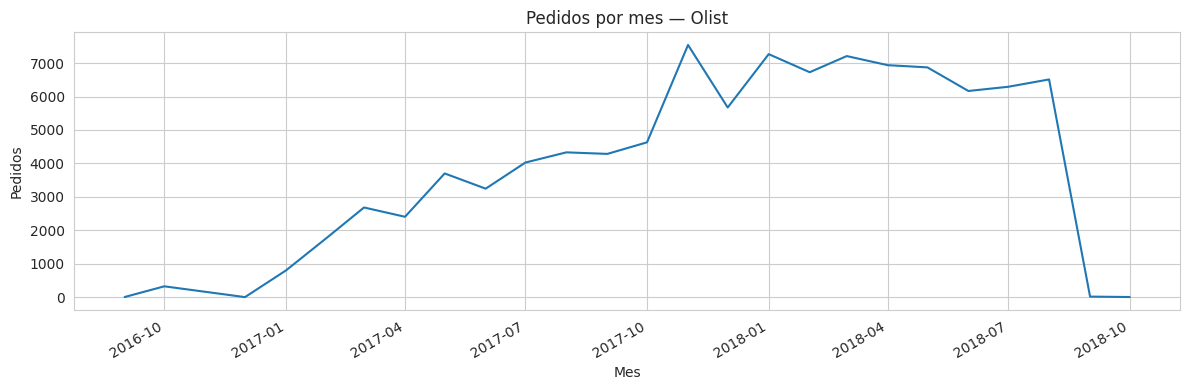

Estados de orden:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [ ]:
orders = dfs['orders'].copy()
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['mes'] = orders['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

monthly = orders.groupby('mes').size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title('Pedidos por mes — Olist')
ax.set_ylabel('Pedidos')
ax.set_xlabel('Mes')
plt.tight_layout()
plt.show()

print('Estados de orden:')
print(orders['order_status'].value_counts())

## 7. Distribución geográfica — clientes y vendedores

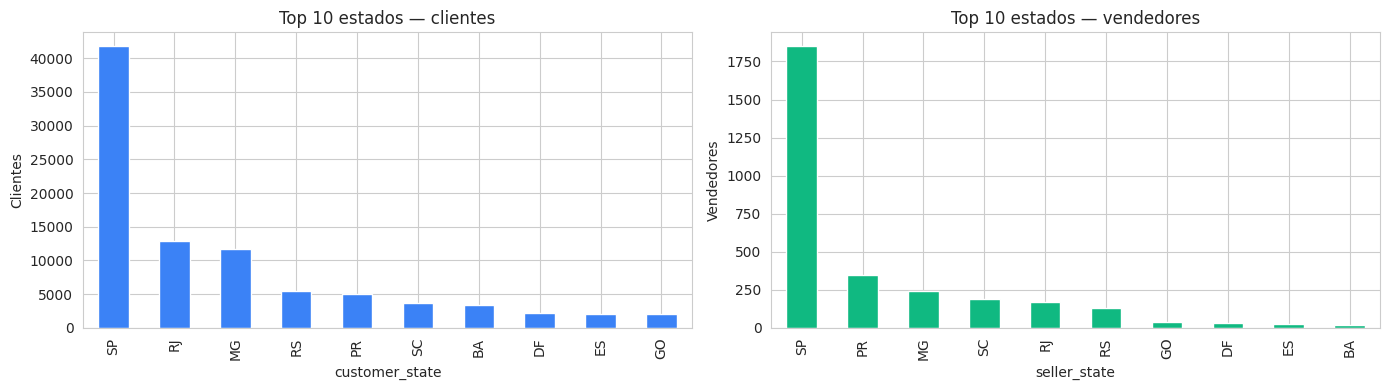

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dfs['customers']['customer_state'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='#3b82f6')
axes[0].set_title('Top 10 estados — clientes')
axes[0].set_ylabel('Clientes')

dfs['sellers']['seller_state'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='#10b981')
axes[1].set_title('Top 10 estados — vendedores')
axes[1].set_ylabel('Vendedores')

plt.tight_layout()
plt.show()

## 8. Reviews — distribución de scoring

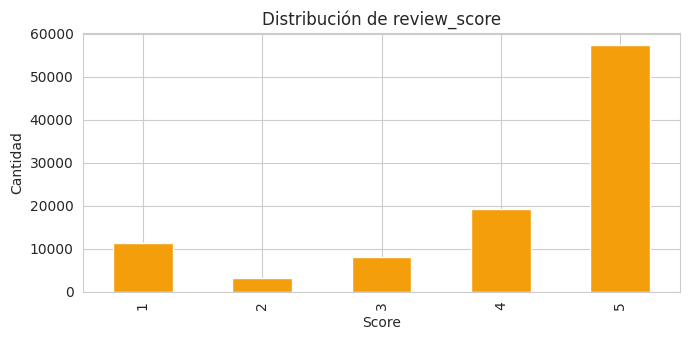

Reviews con comentario: 40,977 de 99,224
Reviews con título:     11,568 de 99,224


In [ ]:
reviews = dfs['order_reviews']
fig, ax = plt.subplots(figsize=(7, 3.5))
reviews['review_score'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#f59e0b')
ax.set_title('Distribución de review_score')
ax.set_xlabel('Score')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

print(f"Reviews con comentario: {reviews['review_comment_message'].notna().sum():,} de {len(reviews):,}")
print(f"Reviews con título:     {reviews['review_comment_title'].notna().sum():,} de {len(reviews):,}")

## 9. Catálogo — atributos heterogéneos (motivación para MongoDB)

In [ ]:
products = dfs['products']
print('Columnas de products:', list(products.columns))

# Nulos por categoría — muestra que distintas categorías llenan distintos atributos
by_cat = (
    products.assign(
        sin_dim=products[['product_length_cm', 'product_height_cm', 'product_width_cm']].isna().any(axis=1),
        sin_peso=products['product_weight_g'].isna(),
        sin_fotos=products['product_photos_qty'].isna(),
    )
    .groupby('product_category_name')[['sin_dim', 'sin_peso', 'sin_fotos']]
    .mean()
    .round(3)
    .sort_values('sin_dim', ascending=False)
    .head(10)
)
by_cat

Columnas de products: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


,sin_dim,sin_peso,sin_fotos
product_category_name,,,
bebes,0.001,0.001,0.0
alimentos,0.000,0.000,0.0
alimentos_bebidas,0.000,0.000,0.0
artes,0.000,0.000,0.0
artes_e_artesanato,0.000,0.000,0.0
artigos_de_festas,0.000,0.000,0.0
artigos_de_natal,0.000,0.000,0.0
audio,0.000,0.000,0.0
agro_industria_e_comercio,0.000,0.000,0.0


## 10. Hallazgos del EDA

Documentar aquí (en celdas markdown) los hallazgos al ejecutar este notebook:

- **Volumen total:** ~99k pedidos, ~32k productos, ~3k vendedores, ~99k reviews.
- **Cobertura temporal:** verificar rango de fechas (esperado: 2016-09 a 2018-10 aprox).
- **Concentración geográfica:** SP (São Paulo) domina tanto en clientes como vendedores.
- **Calidad de datos:** La tabla geolocation	cuenta con 261,831, las demas tablas 0.
  
  La tabla geolocation contiene un volumen importante de duplicados exactos. Esto puede explicarse porque múltiples registros comparten:

  *  mismo código postal
  *  misma ciudad,
  *  mismas coordenadas.


- **Integridad:** El análisis temporal de órdenes muestra el comportamiento operativo del negocio a lo largo del tiempo.
Existe crecimiento progresivo de pedidos:
  *  Se observan patrones de estacionalidad.
  *  Hay concentración de órdenes durante ciertos periodos comerciales.
  
  El crecimiento puede estar asociado a expansión del marketplace, incorporación de vendedores, incremento de clientes activos. También es posible detectar: picos por campañas, eventos comerciales, temporadas altas.

- **Justificación arquitectónica:** la sección 9 muestra heterogeneidad de atributos por categoría → confirma decisión de modelar `products` en MongoDB.

> Estos hallazgos alimentan directamente las Etapas 2 y 3.